In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df=pd.read_csv(url)
print(f"Columns:{list(df.columns)}")

Columns:['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [2]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
df['Age']=df['Age'].fillna(df['Age'].median())
df=df.drop(columns=['Cabin'])
df=df.dropna(subset=['Embarked'])
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [4]:
df['FamilySize'] = df['SibSp']+ df['Parch'] + 1
print(f"Columns:{list(df.columns)}")

Columns:['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize']


In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  FamilySize  Sex_encoded  
0      0         A/5 21171   7.2500        S           2            1  
1      0          PC 17599  71.2833        C           2            0  
2      0  STON/O2. 3101282   7.9250        S           1            0  
3      0            113803  53.1

In [6]:
X = df[['Pclass', 'Sex_encoded', 'Age', 'Fare', 'FamilySize']]
y = df['Survived']

**Cross Validation**

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(random_state=42)
scores=cross_val_score(rf_model,X,y,cv=5)
print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print(f"Standard Deviation: {scores.std():.4f}")

CV Scores: [0.78651685 0.80898876 0.85393258 0.79213483 0.85310734]
Mean Accuracy: 0.8189360756681265
Standard Deviation: 0.0292


***Tuning Paramter for Hypertuning***

In [8]:
# IsAlone — 1 if travelling alone, 0 if with family
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Title — extracted from name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
# Simplify titles
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 
     'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Encode Title
df['Title_encoded'] = pd.factorize(df['Title'])[0]
# Check unique titles found
print("Unique titles:", df['Title'].unique())

# Check IsAlone distribution
print("\nIsAlone counts:")
print(df['IsAlone'].value_counts())

# Check first 5 rows of new features
print("\nNew features:")
print(df[['Name', 'Title', 'Title_encoded', 'FamilySize', 'IsAlone']].head())

Unique titles: ['Mr' 'Mrs' 'Miss' 'Master' 'Rare']

IsAlone counts:
IsAlone
1    535
0    354
Name: count, dtype: int64

New features:
                                                Name Title  Title_encoded  \
0                            Braund, Mr. Owen Harris    Mr              0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs              1   
2                             Heikkinen, Miss. Laina  Miss              2   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs              1   
4                           Allen, Mr. William Henry    Mr              0   

   FamilySize  IsAlone  
0           2        0  
1           2        0  
2           1        1  
3           2        0  
4           1        1  


In [9]:
X = df[['Pclass', 'Sex_encoded', 'Age', 'Fare', 'FamilySize','Title_encoded']]
y = df['Survived']
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'Sex_encoded',
       'IsAlone', 'Title', 'Title_encoded'],
      dtype='object')


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(711, 6) (178, 6)
(711,) (178,)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Create model
rf_model = RandomForestClassifier(random_state=42)

# 2. Train model
rf_model.fit(X_train, y_train)

# 3. Predict
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2%}")

Random Forest Accuracy: 78.09%


In [12]:
scores = cross_val_score(rf_model, X, y, cv=5)
print(f"CV mean accuracy: {scores.mean():.2%}")
print(f"CV std: {scores.std():.2%}")

CV mean accuracy: 81.78%
CV std: 3.78%


In [13]:
from sklearn.model_selection import GridSearchCV

# Step 1 — define combinations to try
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# Step 2 — create GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Step 3 — run it (takes 1-2 mins)
grid_search.fit(X_train, y_train)

# Step 4 — print results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.2%}")

# Step 5 — test accuracy
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best):.2%}")

Best parameters: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 85.65%
Test accuracy: 79.21%


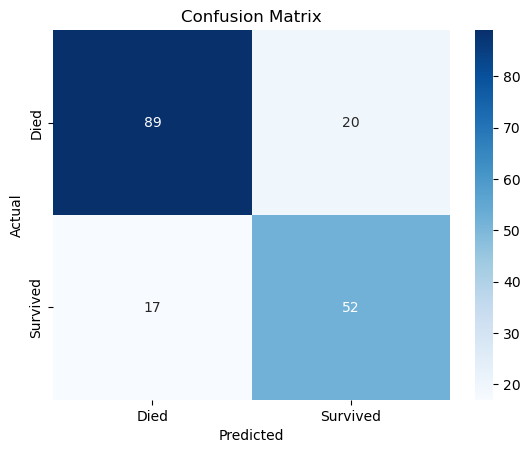

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [15]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest (default)',
        'Random Forest (new features)',
        'Random Forest (tuned)'
    ],
    'CV Accuracy': [
        '~79%',
        '81.89%',
        '81.78%',
        '85.65%'
    ]
})

print(results)

                          Model CV Accuracy
0           Logistic Regression        ~79%
1       Random Forest (default)      81.89%
2  Random Forest (new features)      81.78%
3         Random Forest (tuned)      85.65%


In [16]:
rf_500 = RandomForestClassifier(n_estimators=500, random_state=42)
scores_500 = cross_val_score(rf_500, X, y, cv=5)
print(f"500 trees CV: {scores_500.mean():.2%}")

500 trees CV: 81.89%


In [17]:
X_no_title = df[['Pclass', 'Sex_encoded', 'Age', 'Fare', 'FamilySize', 'IsAlone']]
scores_no_title = cross_val_score(
    RandomForestClassifier(random_state=42), 
    X_no_title, y, cv=5)
print(f"Without Title CV: {scores_no_title.mean():.2%}")

Without Title CV: 81.33%


In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
scores_knn = cross_val_score(knn, X, y, cv=5)
print(f"KNN CV accuracy: {scores_knn.mean():.2%}")

KNN CV accuracy: 71.88%
